
## Lab1.1: Análisis exploratorio de datos con PANDAS y NUMPY

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = sns.load_dataset("penguins").dropna().values
df = pd.DataFrame(data, columns=["especie", "isla", "longitud_pico (mm)", "profundidad_pico (mm)", "longitud_aleta (mm)", "masa_corporal (g)", "genero"])

Esto cargará un dataframe (df), usando la librería seaborn, con algunas características morfológicas y geográficas de diferentes especies de pingüinos. Las columnas contienen los siguientes datos:

```
[especie, isla, longitud del pico, profundidad del pico, longitud de la aleta, masa corporal, genero]
```

https://github.com/allisonhorst/palmerpenguins/blob/main/man/figures/lter_penguins.png

![see](https://github.com/allisonhorst/palmerpenguins/blob/main/man/figures/lter_penguins.png?raw=true)

In [47]:
df

,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
328,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
329,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
330,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
331,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


## Laboratorio 1

1.   ¿Cuáles son las profundidades del pico máxima y mínima de los pinguinos de la isla Torgersen?

In [48]:
df_tor=df[df['isla']=="Torgersen"]
pico_min=min(df_tor['profundidad_pico (mm)'])
pico_max=max(df_tor['profundidad_pico (mm)'])

print(f'Las profundidades mínima y máxima del pico para los pinguinos de la isla Torgersen son, respectivamente: {pico_min}mm y {pico_max}mm')

Las profundidades mínima y máxima del pico para los pinguinos de la isla Torgersen son, respectivamente: 15.9mm y 21.5mm


2.    ¿De qué isla, especie y género es el pingüino con la mayor masa corporal?
       **Ayuda:** utilice la función `argmax()`

In [49]:
pinguino_gor=df['masa_corporal (g)'].argmax()

print(f'El pinguino con más masa corporal ({df.iloc[pinguino_gor]['masa_corporal (g)']}g) es de la isla {df.iloc[pinguino_gor]['isla']}, especie {df.iloc[pinguino_gor]['especie']} y género {df.iloc[pinguino_gor]['genero']}.')

El pinguino con más masa corporal (6300.0g) es de la isla Biscoe, especie Gentoo y género Male.


3.   ¿Cuál es la masa corporal media de los pinguinos macho que no son de la especie Gentoo?

In [50]:
df_ng=df[df['especie']!="Gentoo"]
df_mng=df_ng[df_ng['genero']=='Male']
mcm=np.mean(df_mng['masa_corporal (g)'])

print(f'La masa corporal media de los pinguinos macho que no son de la especie Gentoo es {np.round(mcm,2)}g.')

La masa corporal media de los pinguinos macho que no son de la especie Gentoo es 4010.28g.


4.   Grafique la distribución de la longitud del pico. Añada el valor medio y la desviación estándar en el título de la figura. **Ayuda:** utilice la funcion `hist()`

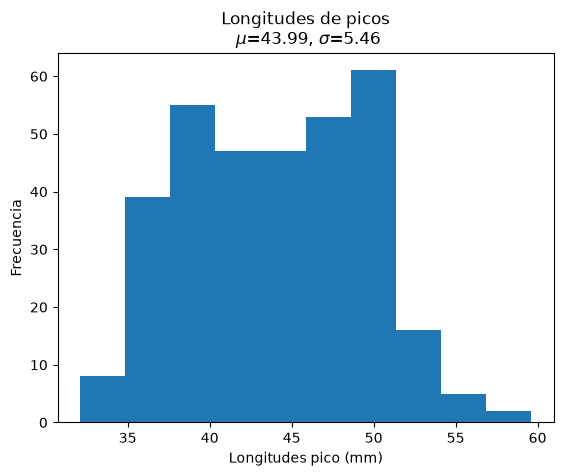

In [51]:
plt.hist(df['longitud_pico (mm)'])
plt.title(f'Longitudes de picos\n $\\mu$={np.round(np.mean(df['longitud_pico (mm)']),2)}, $\\sigma$={np.round(np.std(df['longitud_pico (mm)']),2)}')
plt.xlabel('Longitudes pico (mm)')
plt.ylabel('Frecuencia')
plt.show()

5.   ¿Cuáles son las islas y especies presentes en el conjunto de datos? ¿Con qué frecuencia aparecen? Grafique la distribución de la masa corporal para los pingüinos.

La isla Biscoe aparece 163 veces
La isla Dream aparece 123 veces
La isla Torgersen aparece 47 veces

La especie Adelie tiene una población de 146
La especie Gentoo tiene una población de 119
La especie Chinstrap tiene una población de 68


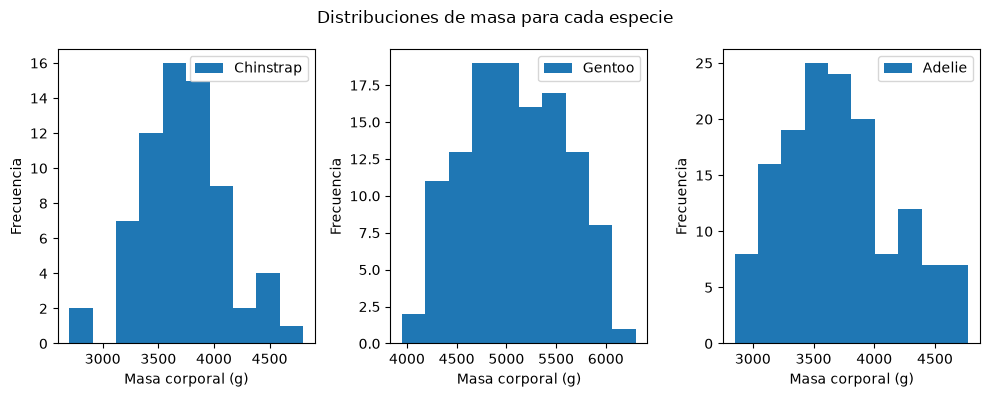

In [65]:
islas=np.array(df['isla'].unique())
especies=np.array(df['especie'].unique())

numi=df['isla'].value_counts()
nume=df['especie'].value_counts()

for cat, cant in numi.items():
    print(f'La isla {cat} aparece {cant} veces')
print('')

for esp, num in nume.items():
    print(f'La especie {esp} tiene una población de {num}')

chins=df[df['especie']=='Chinstrap']
gentoo=df[df['especie']=='Gentoo']
adelie=df[df['especie']=='Adelie']

fig,axes=plt.subplots(1, 3, figsize=(10, 4))
fig.suptitle('Distribuciones de masa para cada especie')

axes[0].hist(chins['masa_corporal (g)'],label='Chinstrap')
axes[0].set_xlabel('Masa corporal (g)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

axes[1].hist(gentoo['masa_corporal (g)'],label='Gentoo')
axes[1].set_xlabel('Masa corporal (g)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

axes[2].hist(adelie['masa_corporal (g)'],label='Adelie')
axes[2].set_xlabel('Masa corporal (g)')
axes[2].set_ylabel('Frecuencia')
axes[2].legend()

plt.tight_layout()
plt.show()

QUIZS TODOS ESTOS HIST EN UNO SOLO....
MUY BIEN. NOTA 5